# CutTrack, minimal version

In [1]:
from datetime import datetime
from unittest.mock import patch

from models import DailyLog, User, CutProfile
from analysis import make_filename, save_profile, load_profile, export_logs_csv, import_logs_csv, plot_weight

## UI-lagret

In [2]:
def show_welcome():
    print("Välkommen till CutTrack.")
    print("Logga vikt, kalorier, protein, steg och träning för att följa din deff.")


def ask_number(prompt):
    while True:
        text = input(prompt)
        try:
            return float(text)
        except ValueError:
            print("Skriv ett tal, till exempel 82.5")


def ask_yes_no(prompt):
    while True:
        answer = input(prompt).strip().lower()
        if answer in ("j", "ja"):
            return True
        elif answer in ("n", "nej"):
            return False
        else:
            print("Svara j eller n.")


def create_profile(name):
    print(f"Ingen profil hittades för {name}. Låt oss skapa en.")
    height_cm = ask_number("Längd i cm: ")
    age = ask_number("Ålder: ")

    sex = ""
    while sex not in ("man", "kvinna"):
        sex = input("Kön (man/kvinna): ").strip().lower()

    start_weight = ask_number("Nuvarande vikt i kg: ")

    goal_weight = None
    while goal_weight is None:
        goal_weight = ask_number("Målvikt i kg: ")
        if goal_weight >= start_weight:
            print("Målvikten måste vara lägre än startvikten.")
            goal_weight = None

    profile = CutProfile(name, height_cm, age, sex, start_weight, goal_weight)
    print(f"Profil skapad för {profile.name}. Proteinmål: {profile.protein_goal()} g/dag.")
    return profile

In [3]:
def log_today(profile):
    date = input("Datum (ÅÅÅÅ-MM-DD), tomt för idag: ").strip()
    if date == "":
        date = datetime.now().strftime("%Y-%m-%d")

    weight = ask_number("Vikt idag (kg): ")
    calories = ask_number("Kalorier idag: ")
    protein = ask_number("Protein idag (g): ")
    steps = ask_number("Steg idag: ")
    trained = ask_yes_no("Tränade du idag? (j/n): ")

    try:
        log = DailyLog(date, weight, calories, protein, int(steps), trained)
        profile.add_log(log)
        print("Loggen sparad för dagen.")
    except ValueError as e:
        print(f"Kunde inte spara loggen: {e}")

In [4]:
def run_menu(profile):
    running = True
    while running:
        print("\n1. Logga dagens data")
        print("2. Visa analys")
        print("3. Visa viktdiagram")
        print("4. Läs in loggar från CSV")
        print("5. Spara och avsluta")
        choice = input("Välj: ").strip()

        if choice == "1":
            log_today(profile)
        elif choice == "2":
            for message in profile.check_goals(days=7):
                print("-", message)
        elif choice == "3":
            plot_weight(profile)
        elif choice == "4":
            filename = input("Filnamn att läsa från: ").strip()
            import_logs_csv(profile, filename)
        elif choice == "5":
            save_profile(profile)
            export_logs_csv(profile)
            print("Hej då!")
            running = False
        else:
            print("Ogiltigt val, försök igen.")

## Test 1: hela menyflödet, utan att sitta och skriva in svar manuellt

Välkommen till CutTrack.
Logga vikt, kalorier, protein, steg och träning för att följa din deff.
Ingen profil hittades för Testperson 1. Låt oss skapa en.
Profil skapad för Testperson 1. Proteinmål: 140.6 g/dag.

1. Logga dagens data
2. Visa analys
3. Visa viktdiagram
4. Läs in loggar från CSV
5. Spara och avsluta
Loggen sparad för dagen.

1. Logga dagens data
2. Visa analys
3. Visa viktdiagram
4. Läs in loggar från CSV
5. Spara och avsluta
- Inte tillräckligt med loggar för att bedöma vikttrenden.
- Proteinmålet nås: snitt 150.0 g mot mål 140.6 g.
- Stegmålet nås: snitt 9000 steg mot mål 8000.
- Träningsmålet nås inte: 1 pass mot mål 3.

1. Logga dagens data
2. Visa analys
3. Visa viktdiagram
4. Läs in loggar från CSV
5. Spara och avsluta


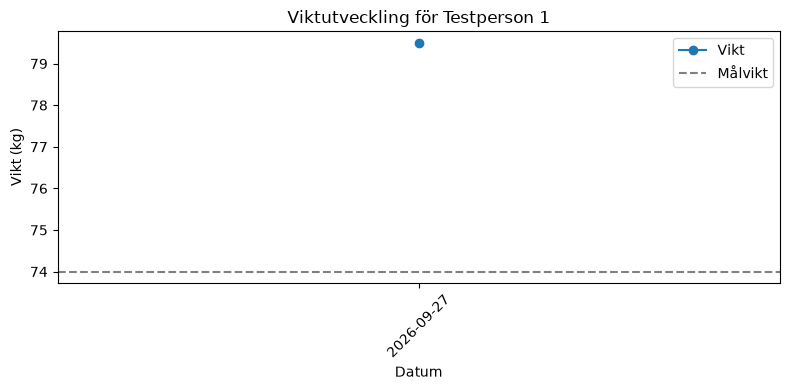

Diagrammet sparat som testperson1_weight_chart.png

1. Logga dagens data
2. Visa analys
3. Visa viktdiagram
4. Läs in loggar från CSV
5. Spara och avsluta
Profilen sparad i testperson1_profile.json
Skapar ny fil: testperson1_logs.csv
Sparade 1 loggar i testperson1_logs.csv
Hej då!

Antal loggar efter körningen: 1


In [5]:
answers = [
    "178", "29", "kvinna", "80", "74",            # create_profile
    "1", "", "79.5", "2000", "150", "9000", "j",  # menyval 1: logga dagen
    "2",                                           # menyval 2: analys
    "3",                                           # menyval 3: diagram
    "5",                                           # menyval 5: spara och avsluta
]

with patch("builtins.input", side_effect=answers):
    show_welcome()
    profile_1 = create_profile("Testperson 1")
    run_menu(profile_1)

print("\nAntal loggar efter körningen:", len(profile_1.logs))

## Test 2: analys på ett större underlag

In [6]:
import random
from datetime import timedelta

profile_2 = CutProfile(
    name="Testperson",
    height_cm=180,
    age=32,
    sex="man",
    start_weight=92.0,
    goal_weight=85.0,
)

random.seed(42)
start_date = datetime(2026, 9, 1)
weight = profile_2.start_weight

for i in range(14):
    date = (start_date + timedelta(days=i)).strftime("%Y-%m-%d")
    weight = round(weight - random.uniform(0.05, 0.2), 1)
    calories = round(random.uniform(1900, 2300))
    protein = round(random.uniform(140, 190))
    steps = round(random.uniform(5000, 11000))
    trained = random.random() < 0.5

    log = DailyLog(date, weight, calories, protein, steps, trained)
    profile_2.add_log(log)

print(f"{profile_2.name} har nu {len(profile_2.logs)} loggar.")

for message in profile_2.check_goals(days=7):
    print("-", message)

Testperson har nu 14 loggar.
- Vikten har gått ner 0.9 kg de senaste 7 loggarna. Rätt riktning.
- Proteinmålet nås inte: snitt 159.3 g mot mål 161.5 g.
- Stegmålet nås: snitt 8332 steg mot mål 8000.
- Träningsmålet nås: 4 pass mot mål 3.
